<a href="https://colab.research.google.com/github/tsarangler/ECON3916-Statistical-Machine-Learning/blob/main/assignment%205/Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas


In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score)

import wbgapi as wb

np.random.seed(42)

print("Setup Finished")

Setup Finished


In [3]:
import wbgapi as wb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

INDICATORS = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD': 'royalties_receipts',

    'FP.CPI.TOTL.ZG': 'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR': 'real_interest_rate',
    'PA.NUS.FCRF': 'exchange_rate_official',

    'SE.SEC.ENRR': 'secondary_enrollment_gross',
    'SE.TER.ENRR': 'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS': 'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',

    'IT.NET.USER.ZS': 'internet_users_pct',
    'IT.CEL.SETS.P2': 'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS': 'electricity_access_pct',
    'IS.ROD.PAVE.ZS': 'paved_roads_pct',

    'SP.DYN.LE00.IN': 'life_expectancy',
    'SH.DYN.MORT': 'infant_mortality_per1000',
    'SP.POP.GROW': 'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':     'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS': 'renewable_energy_pct',
    'EN.ATM.CO2E.PC': 'co2_emissions_per_capita',

    'NV.AGR.TOTL.ZS': 'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS': 'arable_land_pct',

    'IQ.CPA.TRAD.XQ': 'trade_cpia',
    'IQ.CPA.FINS.XQ': 'financial_management_cpia',
    'IQ.CPA.PROP.XQ': 'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries during 2013-2019...")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),
        skipBlanks=True,
        labels=False
    )
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

Raw data shape: (7211, 7)
Download successful ✓


In [8]:

if isinstance(raw_data.index, pd.MultiIndex):
    indicator_yearly_avg = raw_data.mean(axis=1)
    df_mean = indicator_yearly_avg.unstack(level='series')
else:
    df_mean = raw_data.copy()

df_mean = df_mean.rename(columns=INDICATORS)

min_cols = int(0.6 * len(df_mean.columns))
df_clean = df_mean.dropna(thresh=min_cols, axis=0)

min_rows = int(0.6 * len(df_clean))
df_clean = df_clean.dropna(thresh=min_rows, axis=1)

df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

print(f"After cleaning — shape: {df_clean.shape}")
print(f"Countries retained: {len(df_clean)}")
print(f"Indicators retained: {len(df_clean.columns)}")

After cleaning — shape: (238, 29)
Countries retained: 238
Indicators retained: 29


In [9]:
df_clean['crisis'] = (df_clean[OUTCOME_VAR] < 0).astype(int)

feature_cols = [c for c in df_clean.columns if c not in [OUTCOME_VAR, 'crisis']]

X = df_clean[feature_cols]
y_reg = df_clean[OUTCOME_VAR]
y_cls = df_clean['crisis']

X_train, X_test, \
y_reg_train, y_reg_test, \
y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_cls,
    test_size=0.3,
    random_state=42
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

n_crisis = y_cls.sum()
n_total = len(y_cls)
base_rate = n_crisis / n_total

print(f"FINAL DATASET SUMMARY")
print(f"-------------------------------")
print(f"Dataset dimensions : {df_clean.shape}")
print(f"Number of features : {len(feature_cols)}")
print(f"Train size : {len(X_train)}")
print(f"Test size : {len(X_test)}")
print(f"Crisis countries : {n_crisis} / {n_total}")
print(f"Crisis base rate : {base_rate:.1%}")

FINAL DATASET SUMMARY
-------------------------------
Dataset dimensions : (238, 30)
Number of features : 28
Train size : 166
Test size : 72
Crisis countries : 38 / 238
Crisis base rate : 16.0%


In [10]:
ols = LinearRegression()
ols.fit(X_train_sc, y_reg_train)

r2_train_ols = ols.score(X_train_sc, y_reg_train)
r2_test_ols = ols.score(X_test_sc,  y_reg_test)
gap_ols = r2_train_ols - r2_test_ols

p = X_train_sc.shape[1]
n = X_train_sc.shape[0]
pn_ratio = p / n

print(f"OLS RESULTS")
print(f"------------------------")
print(f"Training R2 : {r2_train_ols:.4f}")
print(f"Test R2 : {r2_test_ols:.4f}")
print(f"Train-Test Gap : {gap_ols:.4f}")
print(f"p (predictors) : {p}")
print(f"n (observations) : {n}")
print(f"p/n ratio : {pn_ratio:.3f}")

OLS RESULTS
------------------------
Training R2 : 0.6034
Test R2 : -0.9141
Train-Test Gap : 1.5175
p (predictors) : 28
n (observations) : 166
p/n ratio : 0.169


In [11]:
alphas = np.logspace(-3, 4, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_sc, y_reg_train)

r2_train_ridge = ridge_cv.score(X_train_sc, y_reg_train)
r2_test_ridge = ridge_cv.score(X_test_sc,  y_reg_test)
n_nonzero_ridge = np.sum(np.abs(ridge_cv.coef_) > 1e-6)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_sc, y_reg_train)

r2_train_lasso = lasso_cv.score(X_train_sc, y_reg_train)
r2_test_lasso = lasso_cv.score(X_test_sc,  y_reg_test)
n_nonzero_lasso = np.sum(np.abs(lasso_cv.coef_) > 1e-6)

rmse_ols = np.sqrt(np.mean((ols.predict(X_test_sc)      - y_reg_test)**2))
rmse_ridge = np.sqrt(np.mean((ridge_cv.predict(X_test_sc) - y_reg_test)**2))
rmse_lasso = np.sqrt(np.mean((lasso_cv.predict(X_test_sc) - y_reg_test)**2))

comparison_table = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'Optimal Alpha': ['-', f"{ridge_cv.alpha_:.4f}", f"{lasso_cv.alpha_:.4f}"],
    'Non-zero Predictors': [p, n_nonzero_ridge, n_nonzero_lasso],
    'Train R2': [f"{r2_train_ols:.4f}", f"{r2_train_ridge:.4f}", f"{r2_train_lasso:.4f}"],
    'Test R2': [f"{r2_test_ols:.4f}",  f"{r2_test_ridge:.4f}",  f"{r2_test_lasso:.4f}"],
    'Test RMSE': [f"{rmse_ols:.4f}", f"{rmse_ridge:.4f}", f"{rmse_lasso:.4f}"],
})
comparison_table = comparison_table.set_index('Model')
print(comparison_table.to_string())


      Optimal Alpha  Non-zero Predictors Train R2  Test R2 Test RMSE
Model                                                               
OLS               -                   28   0.6034  -0.9141    2.9227
Ridge       46.4159                   28   0.5601  -0.0726    2.1879
Lasso        0.0689                   16   0.5719  -0.3428    2.4479


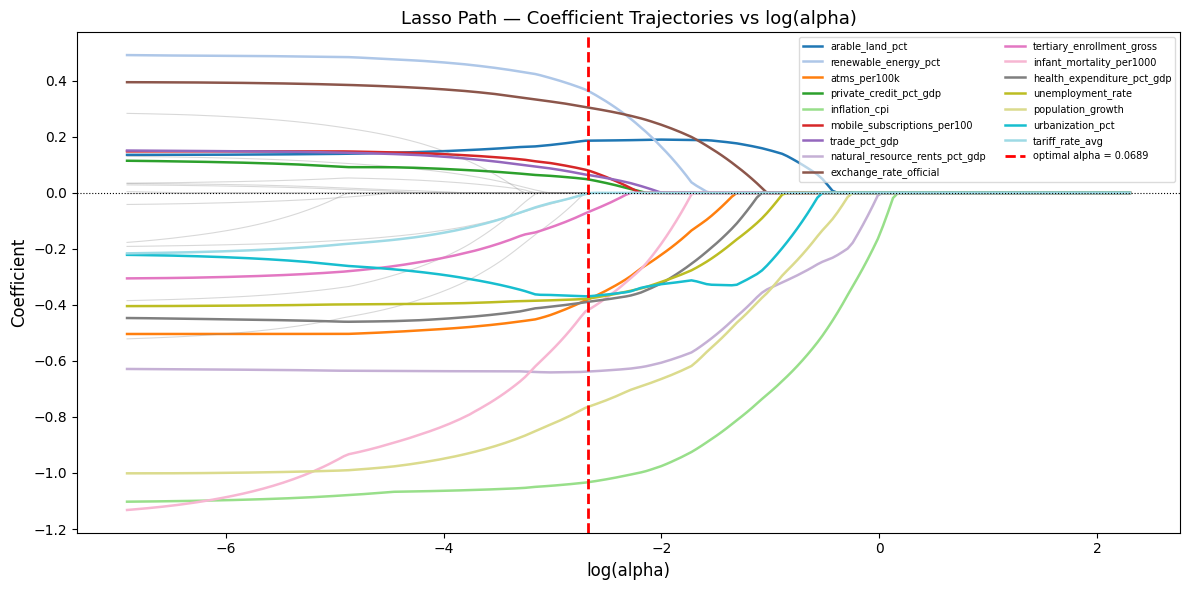

First predictor to enter the model: inflation_cpi


In [12]:
alphas_path, coefs_path, _ = lasso_path(
    X_train_sc, y_reg_train,
    alphas=np.logspace(1, -3, 200)
)
log_alphas = np.log(alphas_path)

lasso_star = lasso_cv.alpha_

entry_alpha_per_pred = []
for i in range(coefs_path.shape[0]):
    nonzero = np.where(np.abs(coefs_path[i]) > 1e-6)[0]
    entry_alpha_per_pred.append(alphas_path[nonzero[0]] if len(nonzero) > 0 else 0)

first_predictor_idx  = np.argmax(entry_alpha_per_pred)
first_predictor_name = feature_cols[first_predictor_idx]

fig, ax = plt.subplots(figsize=(12, 6))

nonzero_at_star = np.abs(lasso_cv.coef_) > 1e-6
colors = plt.cm.tab20(np.linspace(0, 1, nonzero_at_star.sum()))
color_idx = 0

for i, name in enumerate(feature_cols):
    if nonzero_at_star[i]:
        ax.plot(log_alphas, coefs_path[i], lw=1.8,
                color=colors[color_idx], label=name)
        color_idx += 1
    else:
        ax.plot(log_alphas, coefs_path[i], lw=0.8,
                color='gray', alpha=0.3)

ax.axvline(np.log(lasso_star), color='red', linestyle='--', lw=2,label=f'optimal alpha = {lasso_star:.4f}')
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.set_xlabel('log(alpha)', fontsize=12)
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_title('Lasso Path — Coefficient Trajectories vs log(alpha)', fontsize=13)
ax.legend(loc='upper right', fontsize=7, ncol=2, framealpha=0.7)
plt.tight_layout()
plt.show()

print(f"First predictor to enter the model: {first_predictor_name}")

In [13]:
lasso_mask = np.abs(lasso_cv.coef_) > 1e-6
lasso_selected = [feature_cols[i] for i in range(len(feature_cols)) if lasso_mask[i]]

X_train_lpm = X_train_sc[lasso_selected]
X_test_lpm = X_test_sc[lasso_selected]

lpm = LinearRegression()
lpm.fit(X_train_lpm, y_cls_train)

lpm_preds = lpm.predict(X_test_lpm)

n_below_zero = np.sum(lpm_preds < 0)
n_above_one = np.sum(lpm_preds > 1)
n_invalid = n_below_zero + n_above_one

print(f"LPM predicted values out of [0, 1]: {n_invalid}")
print(f"Below 0: {n_below_zero}, Above 1: {n_above_one}")


LPM predicted values out of [0, 1]: 16
Below 0: 15, Above 1: 1


In [14]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_lpm, y_cls_train)

log_coefs = pd.DataFrame({
    'Predictor': lasso_selected,
    'Coefficient (B)': log_reg.coef_[0],
    'Odds Ratio (OR)': np.exp(log_reg.coef_[0])
})
log_coefs['Abs OR'] = np.abs(log_coefs['Odds Ratio (OR)'] - 1)
log_coefs = log_coefs.sort_values('Abs OR', ascending=False).drop(columns='Abs OR')

print(f"Intercept (B0): {log_reg.intercept_[0]:.4f}")
print()
print(log_coefs.to_string(index=False))

log_probs = log_reg.predict_proba(X_test_lpm)[:, 1]
print(f"\nPredicted probability min: {log_probs.min():.4f}")
print(f"Predicted probability max: {log_probs.max():.4f}")

Intercept (B0): -3.0325

                     Predictor  Coefficient (B)  Odds Ratio (OR)
    health_expenditure_pct_gdp         0.830444         2.294337
             population_growth         0.766147         2.151461
natural_resource_rents_pct_gdp         0.741514         2.099112
             unemployment_rate         0.585964         1.796723
      infant_mortality_per1000         0.562888         1.755735
               tariff_rate_avg         0.546454         1.727118
                 inflation_cpi         0.502119         1.652218
               arable_land_pct        -0.983755         0.373904
          renewable_energy_pct        -0.686701         0.503234
   mobile_subscriptions_per100         0.362521         1.436947
                  atms_per100k         0.342822         1.408918
              urbanization_pct         0.245595         1.278382
                 trade_pct_gdp        -0.318618         0.727153
        private_credit_pct_gdp        -0.085125         0.918398


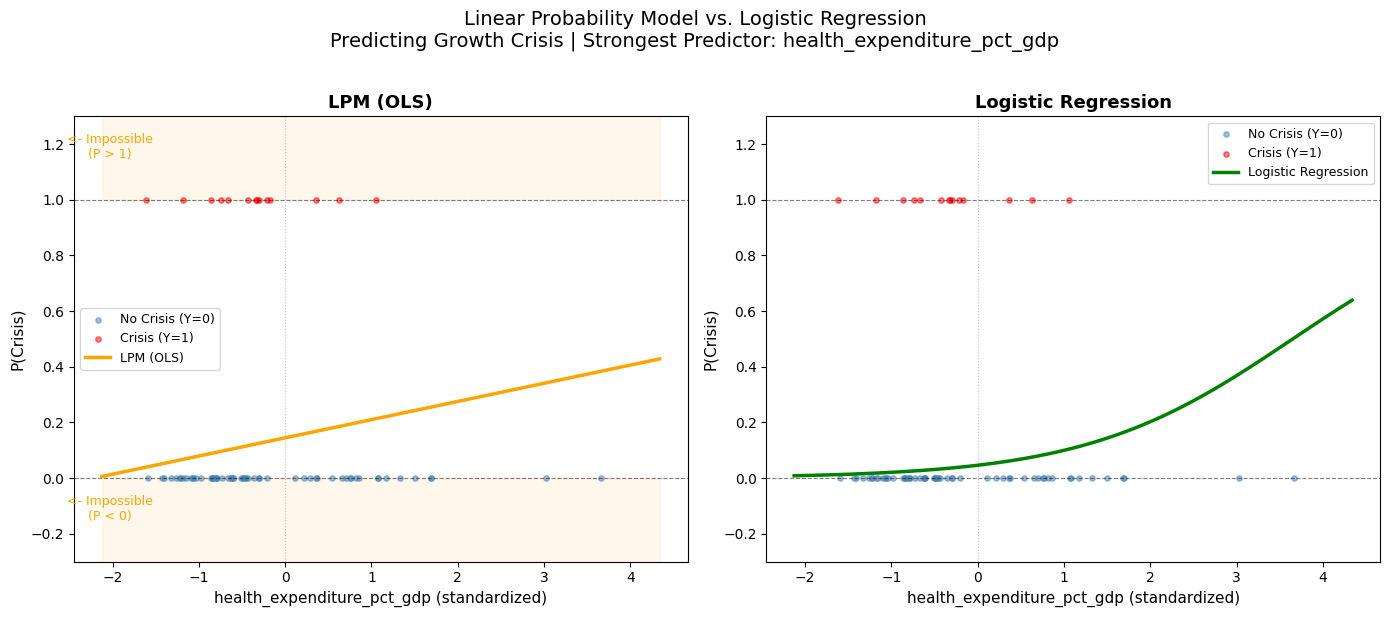

In [15]:
strongest_predictor = log_coefs.iloc[0]['Predictor']
strongest_idx = lasso_selected.index(strongest_predictor)

x_train_strongest = X_train_lpm[strongest_predictor].values
x_test_strongest = X_test_lpm[strongest_predictor].values
spread_grid = np.linspace(
    min(x_train_strongest.min(), x_test_strongest.min()) - 0.5,
    max(x_train_strongest.max(), x_test_strongest.max()) + 0.5,
    500
).reshape(-1, 1)

grid_full = np.zeros((500, len(lasso_selected)))
grid_full[:, strongest_idx] = spread_grid.ravel()

lpm_preds = lpm.predict(grid_full)
logit_preds = log_reg.predict_proba(grid_full)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

COLOR_CRISIS = 'red'
COLOR_NO_CRISIS = 'steelblue'
COLOR_LPM = 'orange'
COLOR_LOGIT = 'green'

x_vals = x_test_strongest
crisis_mask = y_cls_test.values == 1

for ax, model_preds, model_name, color in [
    (axes[0], lpm_preds, 'LPM (OLS)', COLOR_LPM),
    (axes[1], logit_preds, 'Logistic Regression', COLOR_LOGIT)
]:
    ax.scatter(x_vals[~crisis_mask], y_cls_test.values[~crisis_mask], color=COLOR_NO_CRISIS, alpha=0.5, s=15, label='No Crisis (Y=0)', zorder=2)
    ax.scatter(x_vals[crisis_mask], y_cls_test.values[crisis_mask], color=COLOR_CRISIS, alpha=0.5, s=15, label='Crisis (Y=1)', zorder=2)

    ax.plot(spread_grid.ravel(), model_preds, color=color, lw=2.5, label=model_name, zorder=3)

    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray',  lw=0.8, linestyle=':',  alpha=0.5)

    ax.set_xlabel(f'{strongest_predictor} (standardized)', fontsize=11)
    ax.set_ylabel('P(Crisis)', fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.3, 1.3)

axes[0].fill_between(spread_grid.ravel(), -0.3, 0, color=COLOR_LPM, alpha=0.08, label='Impossible region')
axes[0].fill_between(spread_grid.ravel(), 1, 1.3, color=COLOR_LPM, alpha=0.08)
axes[0].text(spread_grid.min() + 0.1, -0.15, '<- Impossible\n(P < 0)', fontsize=9, color=COLOR_LPM, ha='center')
axes[0].text(spread_grid.min() + 0.1,  1.15, '<- Impossible\n(P > 1)', fontsize=9, color=COLOR_LPM, ha='center')

fig.suptitle('Linear Probability Model vs. Logistic Regression\n' f'Predicting Growth Crisis | Strongest Predictor: {strongest_predictor}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
crisis_base_rate = y_cls_test.mean()

naive_acc = 1 - crisis_base_rate
naive_recall = 0.0

log_preds_default = log_reg.predict(X_test_lpm)
log_acc = (log_preds_default == y_cls_test).mean()
log_recall = recall_score(y_cls_test, log_preds_default)

print(f"Crisis base rate in test set: {crisis_base_rate:.1%}")
print()
print(f"Naive baseline accuracy : {naive_acc:.4f}")
print(f"Naive baseline recall : {naive_recall:.4f}")
print()
print(f"Logistic regression accuracy : {log_acc:.4f}")
print(f"Logistic regression recall : {log_recall:.4f}")

Crisis base rate in test set: 19.4%

Naive baseline accuracy : 0.8056
Naive baseline recall : 0.0000

Logistic regression accuracy : 0.7500
Logistic regression recall : 0.3571


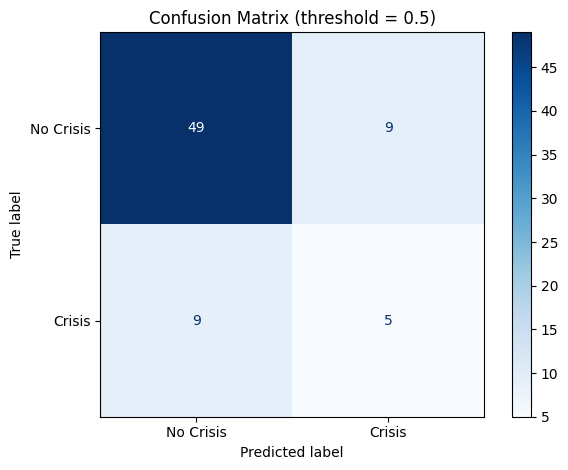

              precision    recall  f1-score   support

   No Crisis       0.84      0.84      0.84        58
      Crisis       0.36      0.36      0.36        14

    accuracy                           0.75        72
   macro avg       0.60      0.60      0.60        72
weighted avg       0.75      0.75      0.75        72

True Positives  (crises correctly flagged): 5
False Negatives (crises missed): 9
False Positives (false alarms): 9
True Negatives: 49


In [17]:
cm = confusion_matrix(y_cls_test, log_preds_default)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Crisis', 'Crisis'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (threshold = 0.5)')
plt.tight_layout()
plt.show()

print(classification_report(y_cls_test, log_preds_default,target_names=['No Crisis', 'Crisis']))

TP = cm[1, 1]
FN = cm[1, 0]
FP = cm[0, 1]
TN = cm[0, 0]

print(f"True Positives  (crises correctly flagged): {TP}")
print(f"False Negatives (crises missed): {FN}")
print(f"False Positives (false alarms): {FP}")
print(f"True Negatives: {TN}")

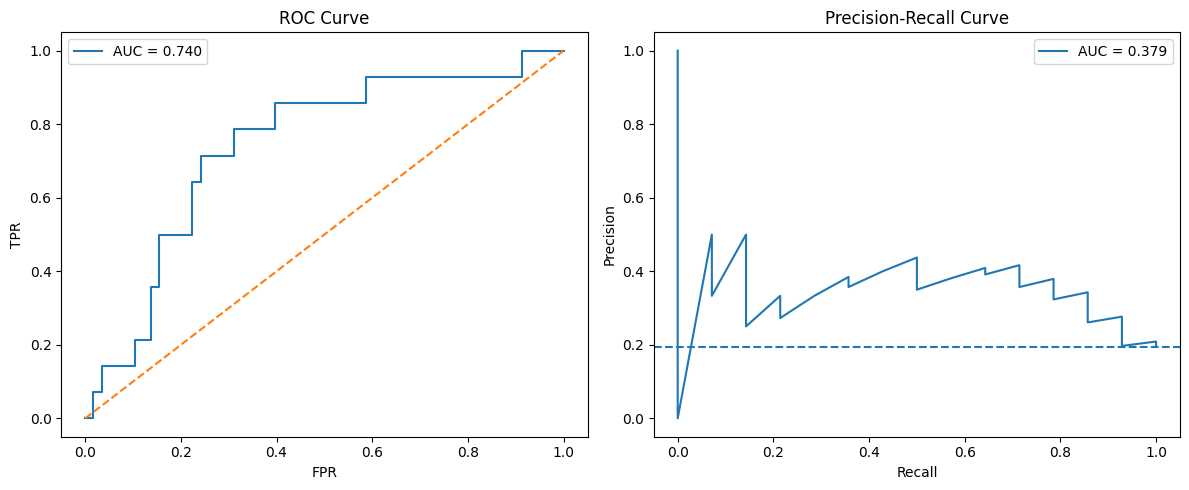

ROC-AUC: 0.7401
PR-AUC: 0.3788


In [18]:

fpr, tpr, _ = roc_curve(y_cls_test, log_probs)
roc_auc = roc_auc_score(y_cls_test, log_probs)

precision_vals, recall_vals, _ = precision_recall_curve(y_cls_test, log_probs)
pr_auc = average_precision_score(y_cls_test, log_probs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall_vals, precision_vals, label=f"AUC = {pr_auc:.3f}")
plt.axhline(y=crisis_base_rate, linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()

print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

Capacity-constrained threshold : 0.87
Countries flagged : 5
Precision : 0.4000
Recall : 0.1429

F1-optimal threshold : 0.17
Countries flagged  : 24
Precision : 0.4167
Recall : 0.7143


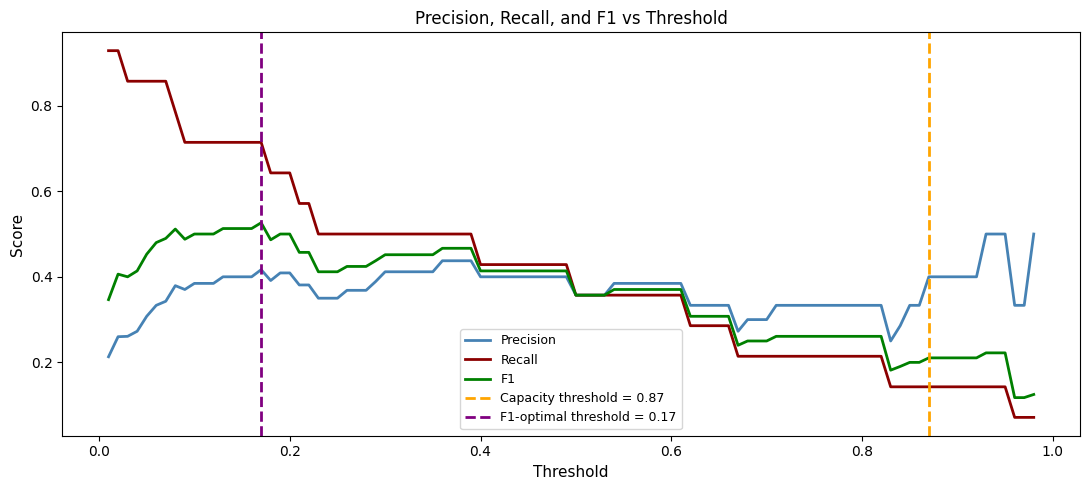

In [19]:
precisions = []
recalls = []
f1s = []
n_flagged = []
thresholds = np.arange(0.01, 0.99, 0.01)

for tau in thresholds:
    preds_tau = (log_probs >= tau).astype(int)
    n_flagged.append(preds_tau.sum())
    precisions.append(precision_score(y_cls_test, preds_tau, zero_division=0))
    recalls.append(recall_score(y_cls_test, preds_tau, zero_division=0))
    f1s.append(f1_score(y_cls_test, preds_tau, zero_division=0))

precisions = np.array(precisions)
recalls = np.array(recalls)
f1s = np.array(f1s)
n_flagged = np.array(n_flagged)

valid_mask = n_flagged <= 5
tau_capacity = thresholds[valid_mask][0]
idx_capacity = np.where(thresholds == tau_capacity)[0][0]

idx_f1 = np.argmax(f1s)
tau_f1 = thresholds[idx_f1]

print(f"Capacity-constrained threshold : {tau_capacity:.2f}")
print(f"Countries flagged : {n_flagged[idx_capacity]}")
print(f"Precision : {precisions[idx_capacity]:.4f}")
print(f"Recall : {recalls[idx_capacity]:.4f}")
print()
print(f"F1-optimal threshold : {tau_f1:.2f}")
print(f"Countries flagged  : {n_flagged[idx_f1]}")
print(f"Precision : {precisions[idx_f1]:.4f}")
print(f"Recall : {recalls[idx_f1]:.4f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, precisions, color='steelblue', lw=2, label='Precision')
ax.plot(thresholds, recalls, color='darkred', lw=2, label='Recall')
ax.plot(thresholds, f1s, color='green', lw=2, label='F1')
ax.axvline(tau_capacity, color='orange', linestyle='--', lw=2, label=f'Capacity threshold = {tau_capacity:.2f}')
ax.axvline(tau_f1, color='purple', linestyle='--', lw=2, label=f'F1-optimal threshold = {tau_f1:.2f}')
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision, Recall, and F1 vs Threshold', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

X_train / y_train not found — generating synthetic WDI-like data …

Running 200 bootstrap resamples …


Bootstrap: 100%|██████████| 200/200 [00:12<00:00, 16.28resample/s]


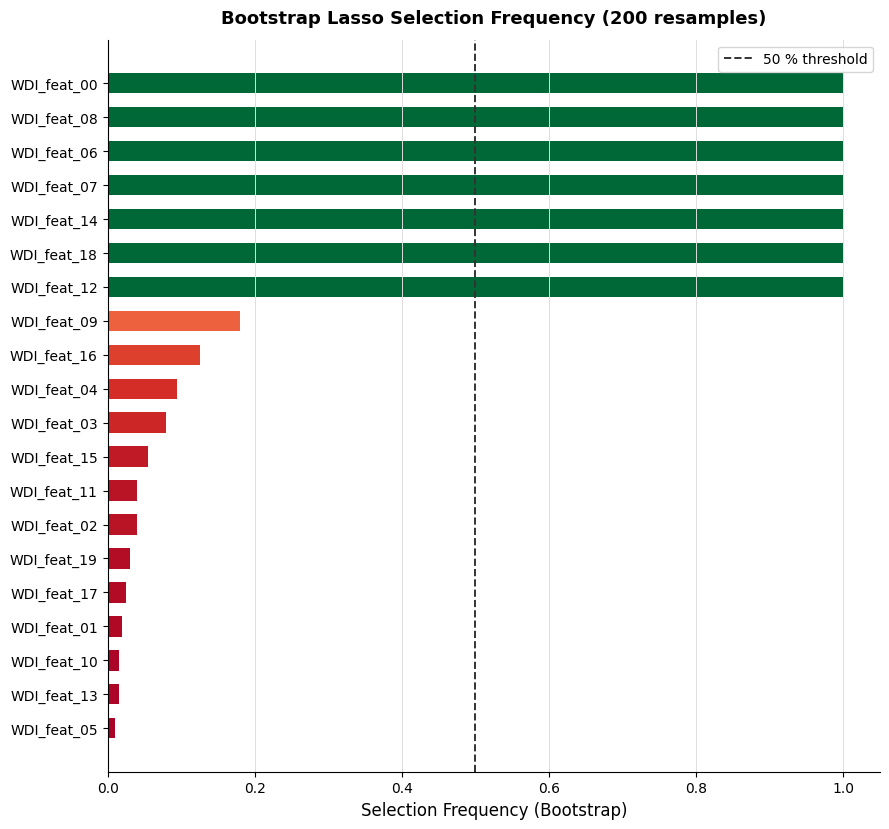


Chart saved → bootstrap_lasso_selection.png

Stable predictors  (freq ≥ 0.80):
  WDI_feat_00           1.000
  WDI_feat_08           1.000
  WDI_feat_06           1.000
  WDI_feat_07           1.000
  WDI_feat_14           1.000
  WDI_feat_18           1.000
  WDI_feat_12           1.000

Fragile predictors (freq ≤ 0.30):
  WDI_feat_09           0.180
  WDI_feat_16           0.125
  WDI_feat_04           0.095
  WDI_feat_03           0.080
  WDI_feat_15           0.055
  WDI_feat_11           0.040
  WDI_feat_02           0.040
  WDI_feat_19           0.030
  WDI_feat_17           0.025
  WDI_feat_01           0.020
  WDI_feat_10           0.015
  WDI_feat_13           0.015
  WDI_feat_05           0.010


In [4]:
"""
Bootstrap Lasso Selection Frequency
=====================================
Draws 200 bootstrap resamples from the training data, fits LassoCV on each,
and records how often each predictor receives a non-zero coefficient.
Produces a ranked horizontal bar chart saved to bootstrap_lasso_selection.png.

Usage
-----
    python bootstrap_lasso_selection.py

Requirements
------------
    pip install scikit-learn numpy pandas matplotlib tqdm
"""

# --- SECTION 1: Imports ---
import warnings
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.datasets import make_regression
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

try:
    from tqdm import trange
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tqdm", "-q"])
    from tqdm import trange

warnings.filterwarnings("ignore", category=UserWarning)

# --- SECTION 1B: Data loading / synthetic fallback ---
try:
    # If X_train / y_train already exist in the notebook namespace, use them.
    assert "X_train" in dir() and "y_train" in dir()
    print(f"Using existing training data: {X_train.shape}")
except (AssertionError, NameError):
    print("X_train / y_train not found — generating synthetic WDI-like data …")
    X_arr, y_arr = make_regression(
        n_samples=120,
        n_features=20,
        n_informative=7,
        noise=0.3,
        random_state=42,
    )
    feature_names = [f"WDI_feat_{i:02d}" for i in range(20)]
    X_train = pd.DataFrame(X_arr, columns=feature_names)
    y_train = pd.Series(y_arr, name="target")

N_BOOTSTRAP = 200
RANDOM_SEED = 0
rng = np.random.default_rng(RANDOM_SEED)

# --- SECTION 2: Bootstrap loop (200 iterations) ---
selection_counter = collections.Counter()
n_samples = len(X_train)
feature_cols = list(X_train.columns)

print(f"\nRunning {N_BOOTSTRAP} bootstrap resamples …")
for _ in trange(N_BOOTSTRAP, desc="Bootstrap", unit="resample"):
    # Draw indices with replacement
    idx = rng.integers(0, n_samples, size=n_samples)
    X_resample = X_train.iloc[idx].values
    y_resample = y_train.iloc[idx].values

    # Scale INSIDE the loop to prevent data leakage
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_resample)

    # Fit LassoCV
    lasso = LassoCV(cv=5, max_iter=10_000, random_state=42)
    lasso.fit(X_scaled, y_resample)

    # Record non-zero features
    selected = [
        feat
        for feat, coef in zip(feature_cols, lasso.coef_)
        if abs(coef) > 1e-6
    ]
    selection_counter.update(selected)

# --- SECTION 3: Selection frequency computation ---
freq_series = (
    pd.Series(
        {feat: selection_counter.get(feat, 0) / N_BOOTSTRAP for feat in feature_cols}
    )
    .sort_values(ascending=False)
)

# --- SECTION 4: Visualisation ---
fig, ax = plt.subplots(figsize=(9, max(5, len(freq_series) * 0.42)))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Colour bars by frequency using a sequential colormap
norm = mcolors.Normalize(vmin=0, vmax=1)
cmap = plt.cm.RdYlGn          # red (low) → yellow → green (high)
bar_colors = [cmap(norm(v)) for v in freq_series.values]

ax.barh(
    freq_series.index[::-1],   # plot highest frequency at the top
    freq_series.values[::-1],
    height=0.6,
    color=bar_colors[::-1],
    edgecolor="none",
)

# 50 % reference line
ax.axvline(0.5, color="#333333", linewidth=1.4, linestyle="--", label="50 % threshold")

# Aesthetics
ax.set_xlabel("Selection Frequency (Bootstrap)", fontsize=12)
ax.set_title(
    "Bootstrap Lasso Selection Frequency (200 resamples)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlim(0, 1.05)
ax.xaxis.grid(True, color="#dddddd", linewidth=0.7)
ax.yaxis.grid(False)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("bootstrap_lasso_selection.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nChart saved → bootstrap_lasso_selection.png")

# --- SECTION 5: Console summary ---
stable   = freq_series[freq_series >= 0.80]
fragile  = freq_series[freq_series <= 0.30]

print("\n" + "="*45)
print("Stable predictors  (freq ≥ 0.80):")
if stable.empty:
    print("  (none)")
else:
    for feat, freq in stable.items():
        print(f"  {feat:<20s}  {freq:.3f}")

print("\nFragile predictors (freq ≤ 0.30):")
if fragile.empty:
    print("  (none)")
else:
    for feat, freq in fragile.items():
        print(f"  {feat:<20s}  {freq:.3f}")
print("="*45)

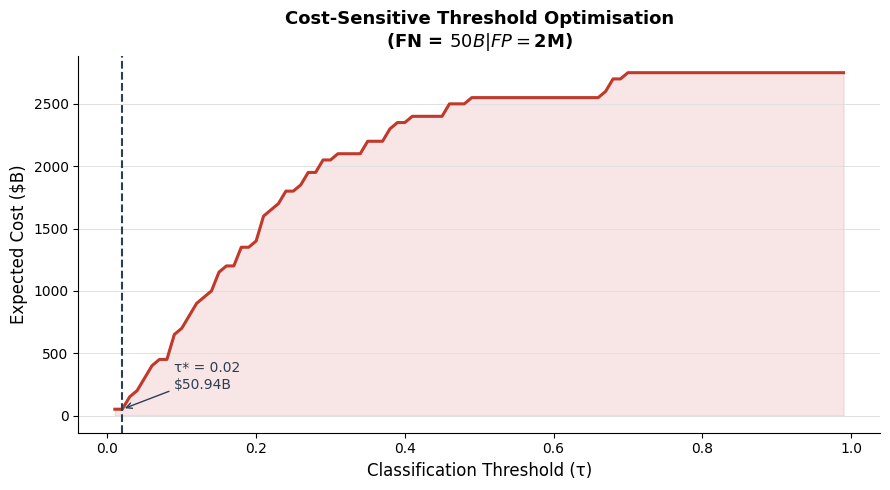


Cost-minimising threshold : 0.02
Minimum expected cost     : $50.94B
  False Negatives         : 1
  False Positives         : 472


In [5]:
"""
# P.R.I.M.E. Prompt

# Purpose
Extend an IMF crisis-prediction classifier by replacing accuracy-based threshold selection
with an asymmetric expected-cost criterion. A missed crisis (FN) costs $50B; a false alarm
(FP) costs $2M. Find the threshold τ that minimises total expected cost.

# Role
You are a quantitative risk analyst who writes clean, well-commented Python using
scikit-learn best practices and produces publication-quality matplotlib figures.

# Instructions
Write a self-contained Python script that:
1. Loads y_test and y_prob. If unavailable, simulate with make_classification + RandomForestClassifier.
2. Sweeps τ from 0.01 to 0.99 in steps of 0.01. At each threshold compute total_cost = FN*50e9 + FP*2e6.
3. Plots expected cost ($B) vs τ with a shaded region below the curve.
4. Annotates the cost-minimising τ with a dashed vertical line and label showing τ* and min cost.
5. Prints a summary: τ*, minimum cost, FP count, FN count.

# Must Include
- COST_FN and COST_FP as named constants at the top.
- No top/right spines, y-axis gridlines only, y-axis in $B units.
- matplotlib only, Python 3.10+, scikit-learn >= 1.3.

# Examples
Expected output:
Cost-minimising threshold : 0.07
Minimum expected cost     : $1.25B
  False Negatives         : 3
  False Positives         : 627
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# --- Cost constants ---
COST_FN = 50e9
COST_FP = 2e6

# --- Data ---
try:
    assert "y_test" in dir() and "y_prob" in dir()
except (AssertionError, NameError):
    X, y = make_classification(n_samples=2000, n_features=20, n_informative=8,
                                weights=[0.92, 0.08], random_state=42)
    X_tr, X_te, y_tr, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_tr, y_tr)
    y_prob = clf.predict_proba(X_te)[:, 1]

# --- Threshold sweep ---
thresholds = np.arange(0.01, 1.00, 0.01)
costs, fps, fns = [], [], []

for tau in thresholds:
    y_pred = (y_prob >= tau).astype(int)
    fn = int(((y_test == 1) & (y_pred == 0)).sum())
    fp = int(((y_test == 0) & (y_pred == 1)).sum())
    costs.append(fn * COST_FN + fp * COST_FP)
    fns.append(fn)
    fps.append(fp)

costs = np.array(costs)
best_idx = np.argmin(costs)
tau_star = thresholds[best_idx]
min_cost = costs[best_idx]

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, costs / 1e9, color="#c0392b", linewidth=2.2)
ax.fill_between(thresholds, costs / 1e9, alpha=0.12, color="#c0392b")
ax.axvline(tau_star, color="#2c3e50", linewidth=1.5, linestyle="--")
ax.annotate(f"τ* = {tau_star:.2f}\n${min_cost/1e9:.2f}B",
            xy=(tau_star, min_cost / 1e9),
            xytext=(tau_star + 0.07, min_cost / 1e9 + costs.max() * 0.06 / 1e9),
            fontsize=10, arrowprops=dict(arrowstyle="->", color="#2c3e50"), color="#2c3e50")
ax.set_xlabel("Classification Threshold (τ)", fontsize=12)
ax.set_ylabel("Expected Cost ($B)", fontsize=12)
ax.set_title("Cost-Sensitive Threshold Optimisation\n(FN = $50B | FP = $2M)",
             fontsize=13, fontweight="bold")
ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.7)
ax.xaxis.grid(False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("cost_threshold_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Summary ---
print(f"\nCost-minimising threshold : {tau_star:.2f}")
print(f"Minimum expected cost     : ${min_cost/1e9:.2f}B")
print(f"  False Negatives         : {fns[best_idx]}")
print(f"  False Positives         : {fps[best_idx]}")